In [27]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Satır: {df.shape[0]:,}  |  Sütun: {df.shape[1]}')
df.head()

Satır: 7,043  |  Sütun: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"NaN sayısı: {df['TotalCharges'].isna().sum()}")

df = df.dropna(subset=['TotalCharges'])
print(f'Temizleme sonrası satır: {len(df):,}')

NaN sayısı: 11
Temizleme sonrası satır: 7,032


In [5]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(df['Churn'].value_counts())
print(f'\nChurn oranı: %{df["Churn"].mean()*100:.1f}')

Churn
0    5163
1    1869
Name: count, dtype: int64

Churn oranı: %26.6


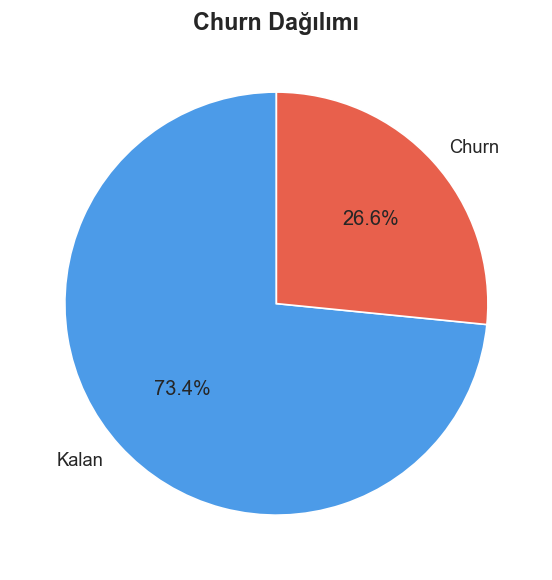

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))

df['Churn'].value_counts().plot(
    kind='pie',
    labels=['Kalan', 'Churn'],
    colors=['#4C9BE8', '#E8604C'],
    autopct='%1.1f%%',
    startangle=90,
    ax=ax
)

ax.set_title('Churn Dağılımı', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

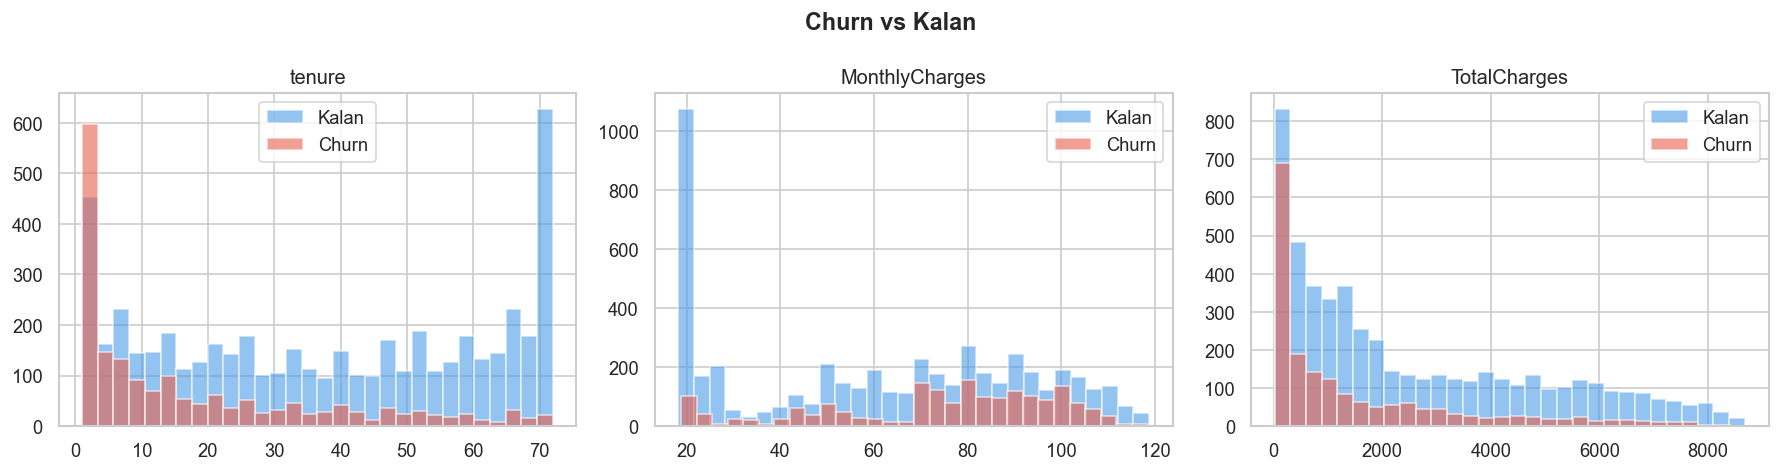

In [7]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(num_cols):
    df[df['Churn'] == 0][col].hist(
        ax=axes[i], alpha=0.6, label='Kalan', color='#4C9BE8', bins=30
    )
    df[df['Churn'] == 1][col].hist(
        ax=axes[i], alpha=0.6, label='Churn', color='#E8604C', bins=30
    )
    axes[i].set_title(col, fontsize=12)
    axes[i].legend()

plt.suptitle('Churn vs Kalan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

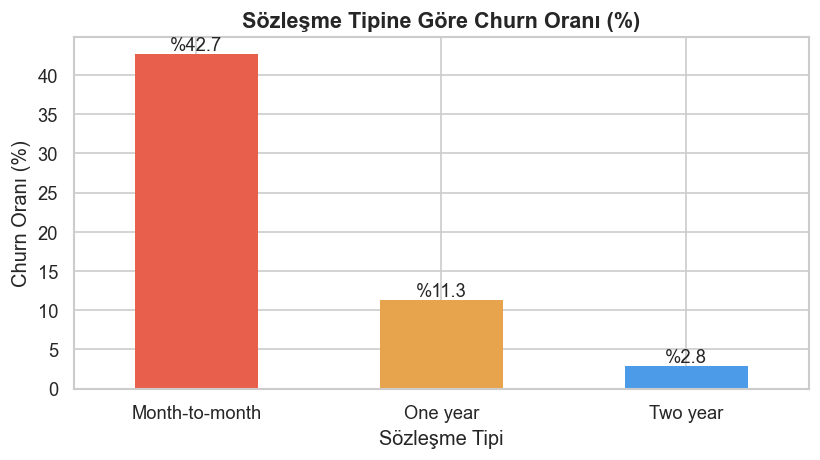

In [8]:
contract_churn = df.groupby('Contract')['Churn'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
contract_churn.sort_values(ascending=False).plot(
    kind='bar', ax=ax, color=['#E8604C', '#E8A44C', '#4C9BE8'], edgecolor='none'
)

ax.set_title('Sözleşme Tipine Göre Churn Oranı (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Sözleşme Tipi')
ax.set_ylabel('Churn Oranı (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for p in ax.patches:
    ax.annotate(f'%{p.get_height():.1f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

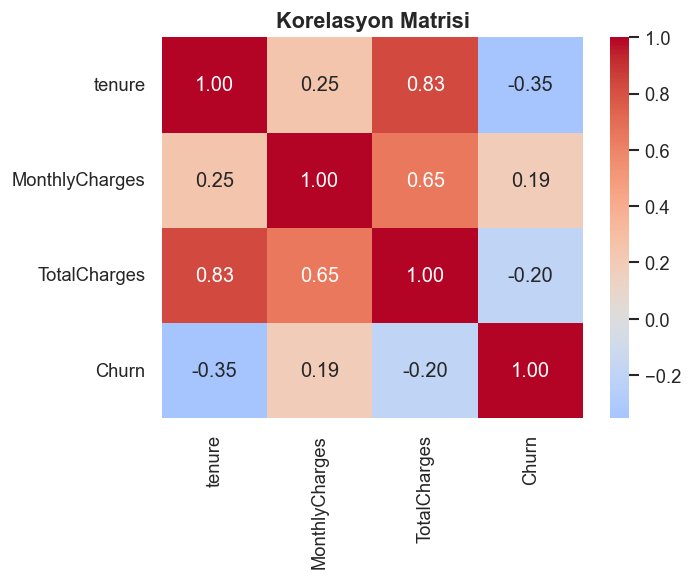

In [9]:
num_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    num_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)

ax.set_title('Korelasyon Matrisi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
def tenure_group(tenure):
    if tenure <= 12:
        return 'Yeni'
    elif tenure <= 24:
        return 'Gelişen'
    else:
        return 'Sadık'

df['tenure_group'] = df['tenure'].apply(tenure_group)

# Her gruptaki churn oranına bak
print(df.groupby('tenure_group')['Churn'].mean() * 100)


tenure_group
Gelişen    28.710938
Sadık      14.036003
Yeni       47.678161
Name: Churn, dtype: float64


In [11]:
# Müşterinin tenure başına ne kadar ödediği
# Yüksekse: kısa sürede çok para ödüyor → churn riski yüksek
df['charges_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# +1 ekledik çünkü tenure=0 olan müşteri olabilir, sıfıra bölme hatası alırız

print(df[['charges_per_tenure', 'Churn']].groupby('Churn').mean())


       charges_per_tenure
Churn                    
0                3.531668
1               11.745880


**Yorum:** Yeni gelmiş ve yüksek paket almış biri için bu değer çok yüksek çıkar. O kişi henüz şirkete bağlanmadan çok para ödüyor — churn riski had safhada.


In [13]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'customerID']  # ID'yi çıkar

print('Dönüştürülecek sütunlar:')
print(cat_cols)

Dönüştürülecek sütunlar:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


In [41]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f'Önceki sütun sayısı: 21')
print(f'Sonraki sütun sayısı: {df_encoded.shape[1]}')
df_encoded.head()

Önceki sütun sayısı: 21
Sonraki sütun sayısı: 35


,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,charges_per_tenure,gender_Male,Partner_Yes,Dependents_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_Sadık,tenure_group_Yeni
0,7590-VHVEG,0,1,29.85,29.85,0,14.925000,False,True,False,...,False,False,False,False,True,False,True,False,False,True
1,5575-GNVDE,0,34,56.95,1889.50,0,1.627143,True,False,False,...,False,False,True,False,False,False,False,True,True,False
2,3668-QPYBK,0,2,53.85,108.15,1,17.950000,True,False,False,...,False,False,False,False,True,False,False,True,False,True
3,7795-CFOCW,0,45,42.30,1840.75,0,0.919565,True,False,False,...,False,False,True,False,False,False,False,False,True,False
4,9237-HQITU,0,2,70.70,151.65,1,23.566667,False,False,False,...,False,False,False,False,True,False,True,False,False,True


In [15]:
# customerID modelde işe yaramaz, sil
df_encoded = df_encoded.drop(columns=['customerID'])

# X: özellikler (features), y: tahmin etmek istediğimiz şey (target)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nChurn dağılımı:')
print(y.value_counts())

X shape: (7032, 33)
y shape: (7032,)

Churn dağılımı:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # %20 test, %80 train
    random_state=42,     # sonuçlar her seferinde aynı çıksın
    stratify=y           # churn oranı train ve test'te eşit 
)

print(f'Train: {X_train.shape[0]:,} satır')
print(f'Test:  {X_test.shape[0]:,} satır')

Train: 5,625 satır
Test:  1,407 satır


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Ölçekle
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modeli kur ve eğit
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print(f'Train accuracy: %{model.score(X_train_scaled, y_train)*100:.1f}')
print(f'Test accuracy:  %{model.score(X_test_scaled, y_test)*100:.1f}')

Train accuracy: %81.0
Test accuracy:  %79.8


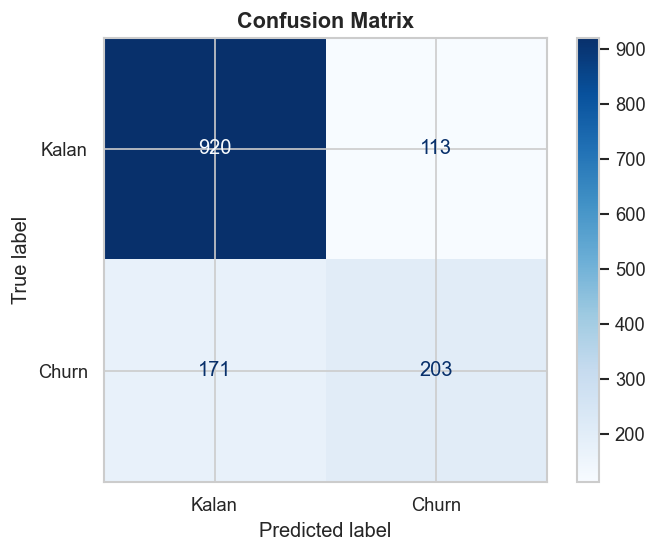

Doğru Kalan tahmini (TN):  920
Yanlış Churn tahmini (FP): 113
Yanlış Kalan tahmini (FN): 171
Doğru Churn tahmini (TP):  203


In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Kalan', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.show()

# Sayıları da yazdır
tn, fp, fn, tp = cm.ravel()
print(f'Doğru Kalan tahmini (TN):  {tn}')
print(f'Yanlış Churn tahmini (FP): {fp}')
print(f'Yanlış Kalan tahmini (FN): {fn}')
print(f'Doğru Churn tahmini (TP):  {tp}')

In [21]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred, target_names=['Kalan', 'Churn']))

auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
print(f'ROC-AUC: {auc:.3f}')

              precision    recall  f1-score   support

       Kalan       0.84      0.89      0.87      1033
       Churn       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407

ROC-AUC: 0.837


E:\CONDA\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


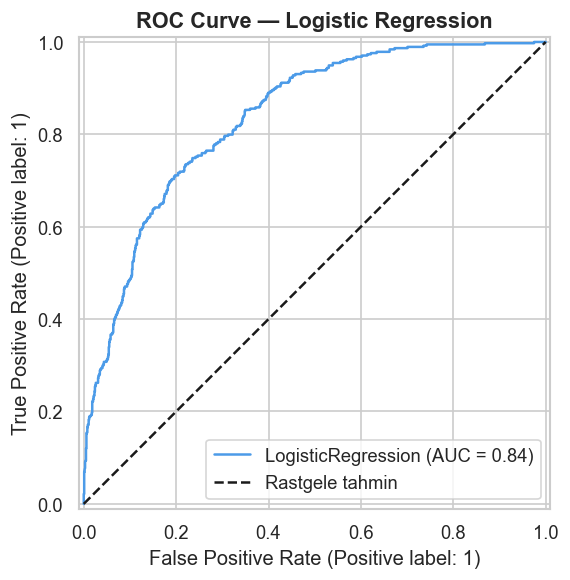

In [22]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_estimator(
    model, X_test_scaled, y_test, ax=ax, color='#4C9BE8'
)

ax.plot([0, 1], [0, 1], 'k--', label='Rastgele tahmin')
ax.set_title('ROC Curve — Logistic Regression', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb.fit(X_train, y_train)  # XGBoost'a scaling gerekmez

y_pred_xgb = xgb.predict(X_test)
auc_xgb = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])

print(f'XGBoost Test accuracy: %{xgb.score(X_test, y_test)*100:.1f}')
print(f'XGBoost ROC-AUC: {auc_xgb:.3f}')
print(f'\nLogistic Regression AUC: 0.840')
print(f'XGBoost AUC:             {auc_xgb:.3f}')

XGBoost Test accuracy: %78.9
XGBoost ROC-AUC: 0.839

Logistic Regression AUC: 0.840
XGBoost AUC:             0.839


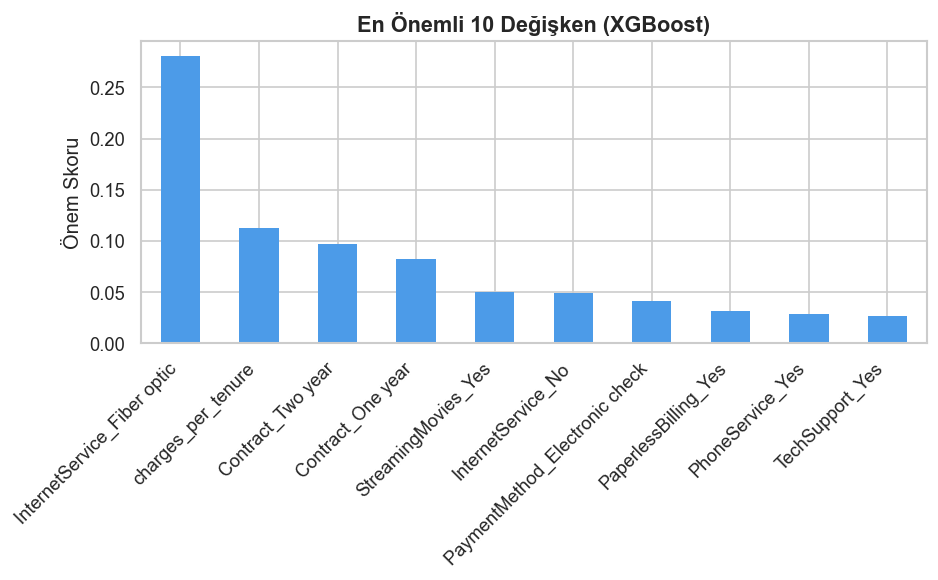

InternetService_Fiber optic       0.281262
charges_per_tenure                0.112508
Contract_Two year                 0.096253
Contract_One year                 0.081852
StreamingMovies_Yes               0.050109
InternetService_No                0.048974
PaymentMethod_Electronic check    0.040977
PaperlessBilling_Yes              0.030719
PhoneService_Yes                  0.028619
TechSupport_Yes                   0.025914
dtype: float32


In [29]:
import pandas as pd

feat_imp = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='bar', ax=ax, color='#4C9BE8', edgecolor='none')
ax.set_title('En Önemli 10 Değişken (XGBoost)', fontsize=13, fontweight='bold')
ax.set_ylabel('Önem Skoru')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(feat_imp)

**En önemli faktörler:**

- **InternetService_Fiber optic (0.28)** — en güçlü sinyal. Fiber internet kullananlar çok daha fazla churn ediyor. Muhtemelen fiyat yüksek, rakipler cazip.
- **charges_per_tenure (0.11)** — bizim türettiğimiz değişken! Ham veride yoktu, biz yarattık ve model onu 2. sıraya koydu. Feature engineering'in gücü bu.
- **Contract_Two year / One year (0.09 / 0.08)** — uzun sözleşme churn'ü engelliyor, EDA'da gördüğümüzü model de doğruladı.



In [37]:
avg_monthly = df['MonthlyCharges'].mean()
churn_count = y_pred_xgb.sum()  # modelin churn dediği müşteri sayısı
avg_tenure_lost = 12  # ortalama kaybedilen ay tahmini

kayip = churn_count * avg_monthly * avg_tenure_lost

print(f'Ortalama aylık ücret:       ${avg_monthly:.0f}')
print(f'Tahmin edilen churn sayısı: {churn_count}')
print(f'Tahmini yıllık kayıp:       ${kayip:,.0f}')
print(f'\n💡 Bu müşterilerin %10\'u elde tutulsa: ${kayip*0.10:,.0f} kurtarılır')

Ortalama aylık ücret:       $65
Tahmin edilen churn sayısı: 307
Tahmini yıllık kayıp:       $238,717

💡 Bu müşterilerin %10'u elde tutulsa: $23,872 kurtarılır


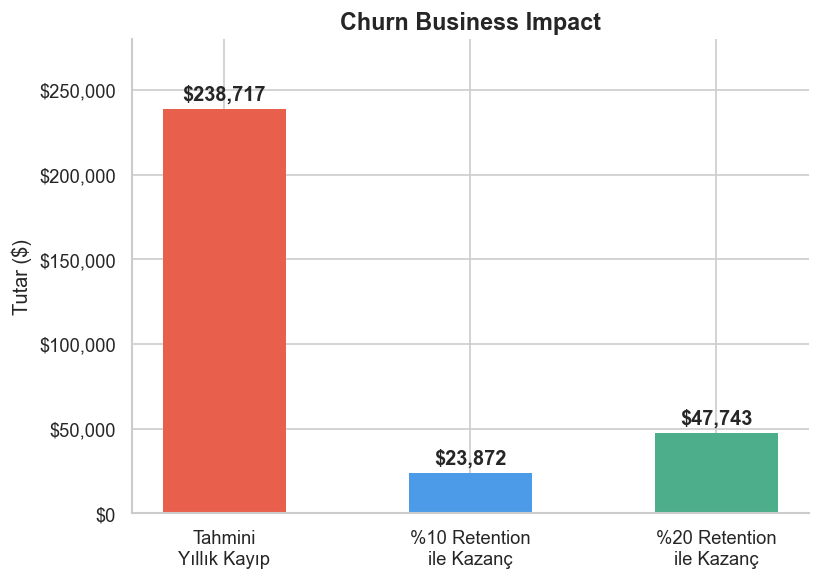

In [42]:
fig, ax = plt.subplots(figsize=(7, 5))

kategoriler = ['Tahmini\nYıllık Kayıp', '%10 Retention\nile Kazanç', '%20 Retention\nile Kazanç']
degerler = [238717, 23872, 47743]
renkler = ['#E8604C', '#4C9BE8', '#4CAE8A']

bars = ax.bar(kategoriler, degerler, color=renkler, edgecolor='none', width=0.5)

for bar, val in zip(bars, degerler):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3000,
        f'${val:,.0f}',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

ax.set_title('Churn Business Impact', fontsize=14, fontweight='bold')
ax.set_ylabel('Tutar ($)')
ax.set_ylim(0, 280000)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.show()

In [44]:
churn_proba = xgb.predict_proba(X_test)[:, 1]

risk_df = X_test.copy()
risk_df['churn_olasiligi'] = churn_proba
risk_df['gercek_durum'] = y_test.values

# En riskli 20 müşteri
top_risk = risk_df.sort_values('churn_olasiligi', ascending=False).head(20)

print('🎯 EN RİSKLİ 20 MÜŞTERİ (öncelikli aksiyon listesi)\n')
print(top_risk[['churn_olasiligi', 'gercek_durum']].to_string())

# Bu listenin ne kadarı gerçekten churn etmiş?
dogruluk = top_risk['gercek_durum'].mean() * 100
print(f'\n💡 En riskli 20 müşterinin %{dogruluk:.0f}\'i gerçekten churn etmiş')

🎯 EN RİSKLİ 20 MÜŞTERİ (öncelikli aksiyon listesi)

      churn_olasiligi  gercek_durum
2753         0.914108             1
3380         0.912133             1
2797         0.911936             1
4585         0.905570             1
2464         0.904731             1
3727         0.893630             1
3085         0.890112             1
2631         0.887065             1
6633         0.886232             1
1073         0.880313             1
5826         0.880095             1
2729         0.877853             1
1807         0.874618             1
3906         0.874579             1
1731         0.871544             1
6190         0.870079             1
6240         0.869051             1
2900         0.868908             1
2367         0.865133             1
85           0.861971             0

💡 En riskli 20 müşterinin %95'i gerçekten churn etmiş


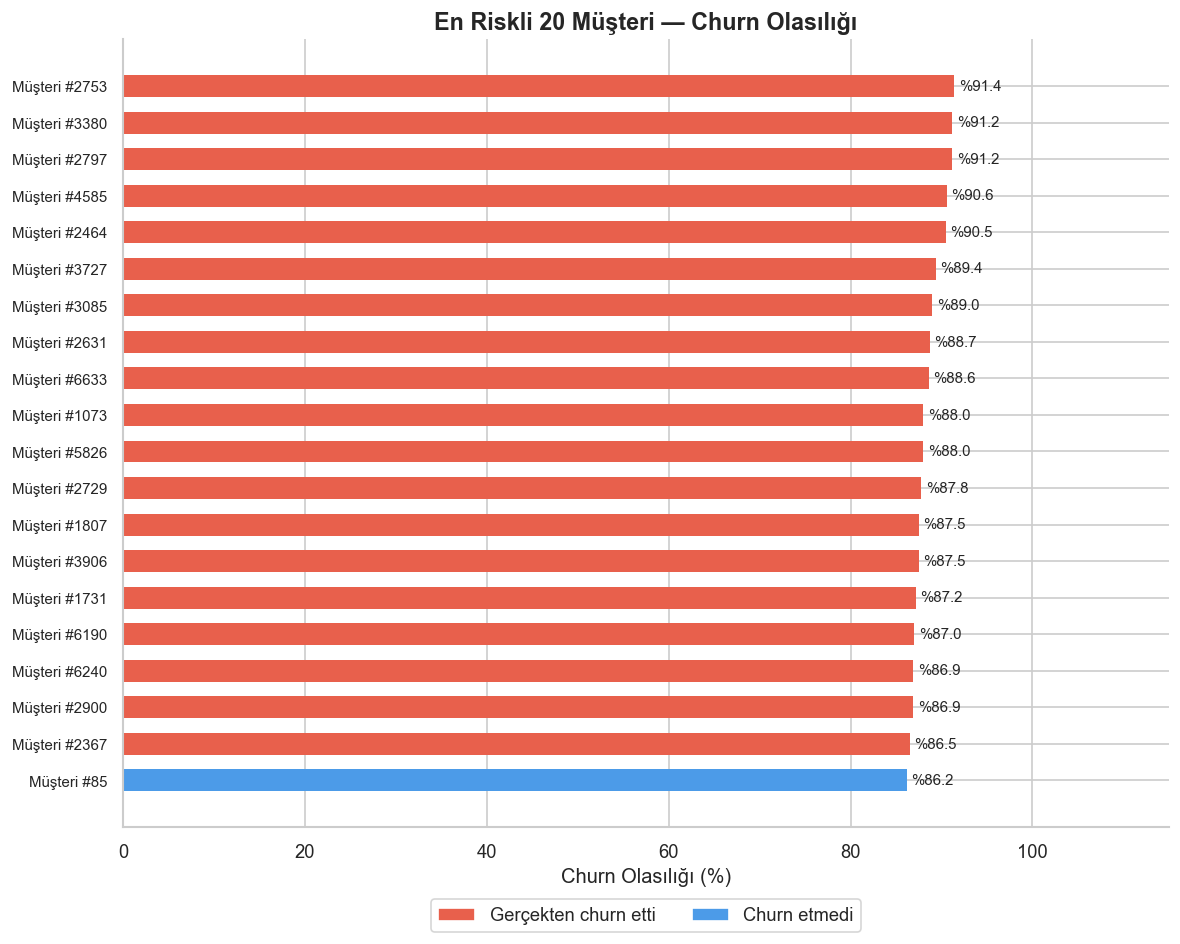

In [51]:
fig, ax = plt.subplots(figsize=(10, 8))

top_risk_reset = top_risk.reset_index()
olasiliklar = (top_risk_reset['churn_olasiligi'] * 100).round(1)
musteri_no = top_risk_reset['index']

renkler = ['#E8604C' if x == 1 else '#4C9BE8' for x in top_risk_reset['gercek_durum']]

y_pos = range(len(top_risk_reset))
bars = ax.barh(y_pos, olasiliklar, color=renkler, edgecolor='none', height=0.6)

for bar, val in zip(bars, olasiliklar):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'%{val:.1f}',
        va='center', fontsize=9
    )

ax.set_yticks(y_pos)
ax.set_yticklabels([f'Müşteri #{idx}' for idx in musteri_no], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Churn Olasılığı (%)')
ax.set_xlim(0, 115)
ax.set_title('En Riskli 20 Müşteri — Churn Olasılığı', fontsize=14, fontweight='bold')

from matplotlib.patches import Patch
legend_el = [
    Patch(facecolor='#E8604C', label='Gerçekten churn etti'),
    Patch(facecolor='#4C9BE8', label='Churn etmedi')
]
ax.legend(handles=legend_el, loc='upper center',
          bbox_to_anchor=(0.5, -0.08), ncol=2)

sns.despine()
plt.tight_layout()
plt.show()